In [1]:
# attempt to match the psf before scaling

# crop the actual image
# use dao on stars (try individual stars - roundness docs)
# calculate average fwhm
# crop an area around the stars with a certain fwhm?

In [2]:
from astropy.io import fits
import numpy as np

oiii_data = np.asarray(fits.open("images/normalized_OIII.fits")[0].data, dtype=np.float32)
oiiic_data = np.asarray(fits.open("images/aligned_normalized_OIIIC.fits")[0].data, dtype=np.float32)

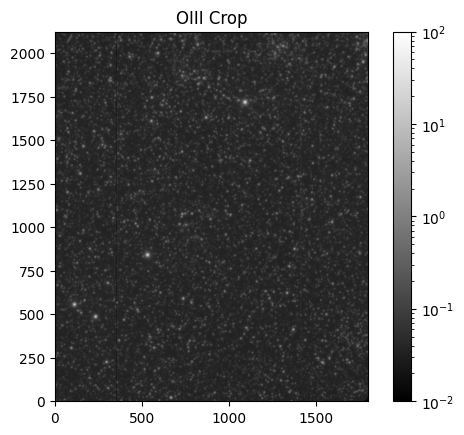

OIII image stats
Min: -0.5434856
Max: 23.724031
Mean: 0.05735035
Stdev: 0.16052462


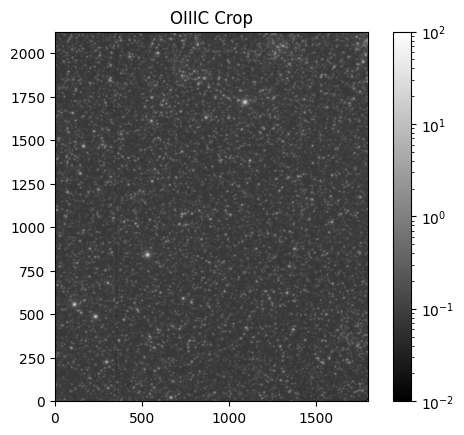

OIIIC image stats
Min: -0.83578134
Max: 25.55434
Mean: 0.12829398
Stdev: 0.27641937


In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# plot oiii stars
oiii_crop = oiii_data[50:, 700:2500]
plt.imshow(oiii_crop, cmap='gray', origin='lower', norm=LogNorm(1e-2, 1e2))
plt.colorbar()
plt.title("OIII Crop")
plt.show()

# oiii info
print("OIII image stats")
print("Min:", np.min(oiii_crop))
print("Max:", np.max(oiii_crop))
print("Mean:", np.mean(oiii_crop))
print("Stdev:", np.std(oiii_crop))

# plot oiiic stars
oiiic_crop = oiiic_data[50:, 700:2500]
plt.imshow(oiiic_crop, cmap='gray', origin='lower', norm=LogNorm(1e-2, 1e2))
plt.colorbar()
plt.title("OIIIC Crop")
plt.show()

# oiiic info
print("OIIIC image stats")
print("Min:", np.min(oiiic_crop))
print("Max:", np.max(oiiic_crop))
print("Mean:", np.mean(oiiic_crop))
print("Stdev:", np.std(oiiic_crop))

In [4]:
# from photutils.psf import fit_fwhm

# fwhm_oiii = fit_fwhm(oiii_crop)
# fwhm_oiiic = fit_fwhm(oiiic_crop)

# print("OIII FWHM:", fwhm_oiii)
# print("OIIIC FWHM:", fwhm_oiiic)

In [5]:
# dao star detection
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder


# OIII stats
mean, median, std = sigma_clipped_stats(oiii_crop)
print(np.array((mean, median, std)))

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundlo=-0.2, roundhi=0.2)
sources_oiii = daofind(oiii_crop - median)
sources_oiii


# OIIIC stats
mean, median, std = sigma_clipped_stats(oiiic_crop)
print(np.array((mean, median, std)))

daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundlo=-0.2, roundhi=0.2)
sources_oiiic = daofind(oiiic_crop - median)
# sources_oiiic = sources_oiii[:100]


# filter top stars

sources_oiii.sort("flux")
sources_oiii.reverse()

sources_oiiic.sort("flux")
sources_oiiic.reverse()

# Keep the brightest 100
sources_oiii = sources_oiii[100:200]
sources_oiiic = sources_oiiic[100:200]

[0.04375814 0.0413223  0.00787578]


[0.0950525  0.08934525 0.01755424]


In [6]:
# import numpy as np
# from photutils.psf import fit_fwhm

# xypos = np.column_stack((
#     sources["x_centroid"],
#     sources["y_centroid"]
# ))

# fwhm = fit_fwhm(
#     oiii_crop,
#     xypos=xypos,
#     fit_shape=31
# )

# print(np.nanmedian(fwhm))

In [7]:
# get star cutouts for psf calibration
from astropy.nddata import Cutout2D


# OIII cutouts
size = 31
stars_oiii = []

for source in sources_oiii:
    x = source["x_centroid"]
    y = source["y_centroid"]
    
    cutout = (Cutout2D(oiii_crop, (x, y), (size, size)).data)
    if cutout.shape == (31, 31):
        stars_oiii.append(cutout)
        
        
# OIIIC cutouts
size = 31
stars_oiiic = []

for source in sources_oiiic:
    x = source["x_centroid"]
    y = source["y_centroid"]
    
    cutout = (Cutout2D(oiiic_crop, (x, y), (size, size)).data)
    if cutout.shape == (31, 31):
        stars_oiiic.append(cutout)

In [8]:
# normalize psfs

# OIII
psfs_oiii = []

for star in stars_oiii:
    psf = star - np.nanmedian(star)

    if np.nansum(psf) > 0:
        psf /= np.nansum(psf)
        psfs_oiii.append(psf)


# OIIIC
psfs_oiiic = []

for star in stars_oiiic:
    psf = star - np.nanmedian(star)

    if np.nansum(psf) > 0:
        psf /= np.nansum(psf)
        psfs_oiiic.append(psf)


In [9]:
print(len(psfs_oiii))
print(len(psfs_oiiic))

psf_oiii = np.nanmedian(psfs_oiii, axis=0)
psf_oiii /= np.nansum(psf_oiii)

psf_oiiic = np.nanmedian(psfs_oiiic, axis=0)
psf_oiiic /= np.nansum(psf_oiiic)

98
97


In [10]:

from photutils.psf_matching import make_kernel, CosineBellWindow


window = CosineBellWindow(alpha=0.8)
kernel = make_kernel(psf_oiiic, psf_oiii, window=window)

(31, 31)
(31, 31)


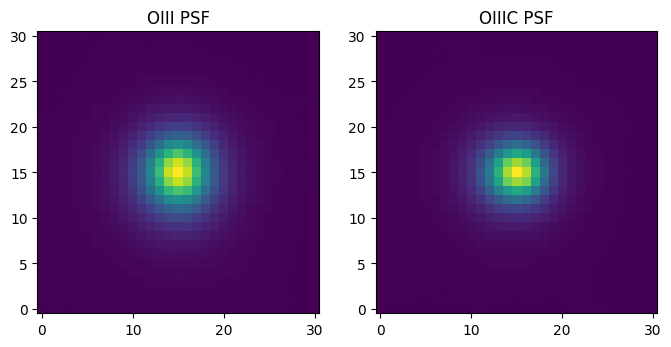

In [11]:
print(psf_oiii.shape)
print(psf_oiiic.shape)

plt.figure(figsize=(8,4))
plt.subplot(121)
plt.imshow(psf_oiii, origin="lower")
plt.title("OIII PSF")

plt.subplot(122)
plt.imshow(psf_oiiic, origin="lower")
plt.title("OIIIC PSF")
plt.show()


# test_convolve = 

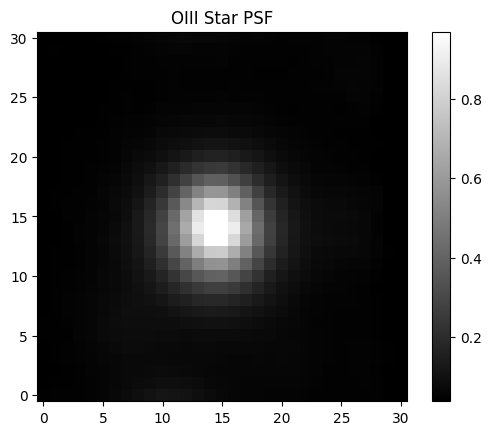

In [12]:
# 1790, 1765 was too bright
# try 1035, 1102

from astropy.nddata import Cutout2D

size = 31
star_oiii = Cutout2D(oiii_data, (1035, 1102), (size, size)).data
plt.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
plt.colorbar()
plt.title("OIII Star PSF")
plt.show()

In [13]:
# from astropy.nddata import Cutout2D

# size = 31
# star_oiiic = Cutout2D(oiiic_data, (1035, 1102), (size, size)).data
# plt.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
# plt.colorbar()
# plt.title("OIIIC Star PSF")
# plt.show()

In [14]:
# OIII PSF
psf_oiii = star_oiii - np.nanmedian(star_oiii)
# psf_oiii[psf_oiii < 0] = 0    # reject negative values
psf_oiii = psf_oiii / np.nansum(psf_oiii)  # normalize

In [15]:
# OIII PSF
# psf_oiiic = star_oiiic - np.nanmedian(star_oiiic)
# psf_oiiic[psf_oiiic < 0] = 0    # reject negative values
# psf_oiiic = psf_oiiic / np.nansum(psf_oiiic)  # normalize

In [16]:
# from photutils.psf import fit_fwhm

# fwhm_oiii = fit_fwhm(star_oiii)
# fwhm_oiiic = fit_fwhm(star_oiiic)

# print("OIII FWHM:", fwhm_oiii)
# print("OIIIC FWHM:", fwhm_oiiic)

In [17]:
# # from photutils.psf_matching import make_kernel
# # kernel = make_kernel(psf_oiii, psf_oiiic)

# from photutils.psf_matching import make_kernel, CosineBellWindow

# window = CosineBellWindow(alpha=0.5)
# kernel = make_kernel(psf_oiiic, psf_oiii, window=window)

In [18]:
import numpy as np
from photutils.psf import fit_fwhm

fit_shape = 15
margin = fit_shape // 2

# ==========================
# OIII
# ==========================
mask_oiii = (
    (sources_oiii["x_centroid"] >= margin) &
    (sources_oiii["x_centroid"] < oiii_crop.shape[1] - margin) &
    (sources_oiii["y_centroid"] >= margin) &
    (sources_oiii["y_centroid"] < oiii_crop.shape[0] - margin)
)

xypos_oiii = np.column_stack((
    sources_oiii["x_centroid"][mask_oiii],
    sources_oiii["y_centroid"][mask_oiii]
))

fwhm_oiii = fit_fwhm(
    oiii_crop,
    xypos=xypos_oiii,
    fit_shape=fit_shape
)

# ==========================
# OIIIC
# ==========================
mask_oiiic = (
    (sources_oiiic["x_centroid"] >= margin) &
    (sources_oiiic["x_centroid"] < oiiic_crop.shape[1] - margin) &
    (sources_oiiic["y_centroid"] >= margin) &
    (sources_oiiic["y_centroid"] < oiiic_crop.shape[0] - margin)
)

xypos_oiiic = np.column_stack((
    sources_oiiic["x_centroid"][mask_oiiic],
    sources_oiiic["y_centroid"][mask_oiiic]
))

fwhm_oiiic = fit_fwhm(
    oiiic_crop,
    xypos=xypos_oiiic,
    fit_shape=fit_shape
)

# ==========================
# Results
# ==========================
print(f"OIII  : median = {np.nanmedian(fwhm_oiii):.2f} px, mean = {np.nanmean(fwhm_oiii):.2f} px")
print(f"OIIIC : median = {np.nanmedian(fwhm_oiiic):.2f} px, mean = {np.nanmean(fwhm_oiiic):.2f} px")

OIII  : median = 7.59 px, mean = 7.67 px
OIIIC : median = 6.34 px, mean = 6.40 px


(31, 31)
1.0


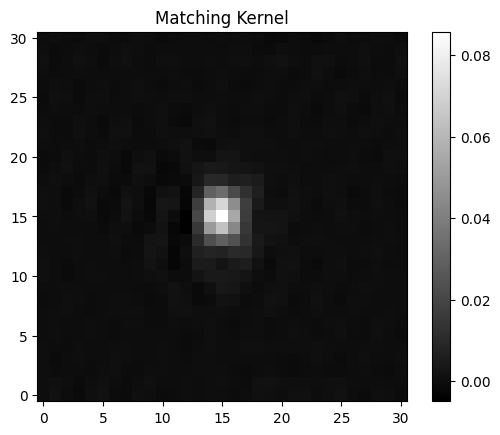

In [19]:
import matplotlib.pyplot as plt

print(kernel.shape)
print(kernel.sum())

plt.imshow(kernel, origin="lower", cmap="gray")
plt.colorbar()
plt.title("Matching Kernel")
plt.show()

(31, 31)
(31, 31)
(31, 31)


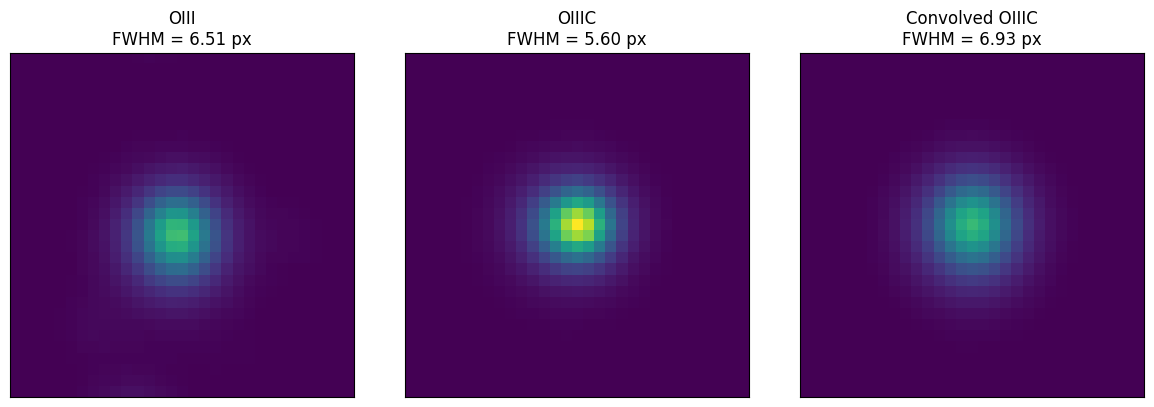

OIII PSF FWHM:            6.51 px
OIIIC PSF FWHM:           5.60 px
Convolved OIIIC PSF FWHM: 6.93 px


In [20]:
print(psf_oiii.shape)
print(psf_oiiic.shape)

# plt.figure(figsize=(8,4))
# plt.subplot(131)
# plt.imshow(psf_oiii, origin="lower")
# plt.title("OIII PSF")

# plt.subplot(132)
# plt.imshow(psf_oiiic, origin="lower")
# plt.title("OIIIC PSF")
# plt.show()


from astropy.convolution import convolve_fft
test_convolve = convolve_fft(psf_oiiic, kernel, normalize_kernel=True, allow_huge=True)
print(test_convolve.shape)
# plt.subplot(133)
# plt.imshow(test_convolve, origin="lower")
# plt.title("OIIIC Conv PSF")
# plt.show()


# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# ax[0].imshow(psf_oiii, origin="lower", cmap="viridis")
# ax[0].set_title("OIII")

# ax[1].imshow(psf_oiiic, origin="lower", cmap="viridis")
# ax[1].set_title("OIIIC")

# ax[2].imshow(test_convolve, origin="lower", cmap="viridis")
# ax[2].set_title("Convolved OIIIC")

# plt.tight_layout()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from photutils.psf import fit_fwhm

# -------------------------
# Measure FWHM of empirical PSFs
# -------------------------
fwhm_psf_oiii = fit_fwhm(psf_oiii)
fwhm_psf_oiiic = fit_fwhm(psf_oiiic)
fwhm_psf_conv = fit_fwhm(test_convolve)

# Use common colour scale
vmax = max(
    np.nanmax(psf_oiii),
    np.nanmax(psf_oiiic),
    np.nanmax(test_convolve)
)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(psf_oiii, origin="lower", cmap="viridis",
             vmin=0, vmax=vmax)
ax[0].set_title(f"OIII\nFWHM = {fwhm_psf_oiii[0]:.2f} px")

ax[1].imshow(psf_oiiic, origin="lower", cmap="viridis",
             vmin=0, vmax=vmax)
ax[1].set_title(f"OIIIC\nFWHM = {fwhm_psf_oiiic[0]:.2f} px")

ax[2].imshow(test_convolve, origin="lower", cmap="viridis",
             vmin=0, vmax=vmax)
ax[2].set_title(f"Convolved OIIIC\nFWHM = {fwhm_psf_conv[0]:.2f} px")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()

print(f"OIII PSF FWHM:            {fwhm_psf_oiii[0]:.2f} px")
print(f"OIIIC PSF FWHM:           {fwhm_psf_oiiic[0]:.2f} px")
print(f"Convolved OIIIC PSF FWHM: {fwhm_psf_conv[0]:.2f} px")


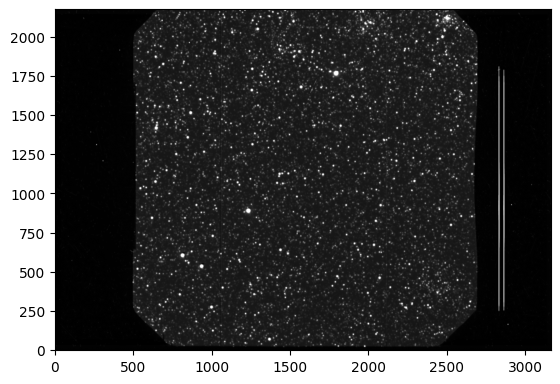

In [21]:
# blur OIII data to match OIIIC data using astropy convolution

from astropy.convolution import convolve_fft
oiiic_convolved = convolve_fft(oiiic_data, kernel, normalize_kernel=True, allow_huge=True)

plt.imshow(oiiic_convolved, cmap='gray', origin='lower', vmin=np.percentile(oiiic_convolved,1), vmax=np.percentile(oiiic_convolved,99.5))
plt.show()

In [22]:
mean, median, std = sigma_clipped_stats(oiiic_convolved)

daofind = DAOStarFinder(
    fwhm=9,
    threshold=5 * std,
    roundlo=-0.2,
    roundhi=0.2
)

sources_conv = daofind(oiiic_convolved - median)

# Keep the brightest 50 (or 100)
sources_conv.sort("flux")
sources_conv.reverse()
sources_conv = sources_conv[:50]

xypos = np.column_stack((
    sources_conv["x_centroid"],
    sources_conv["y_centroid"]
))

fwhm_conv = fit_fwhm(
    oiiic_convolved,
    xypos=xypos,
    fit_shape=15
)

print("Convolved OIIIC median FWHM:", np.nanmedian(fwhm_conv))

Convolved OIIIC median FWHM: 7.374461441872953


In [23]:
# from astropy.nddata import Cutout2D
# from photutils.psf import fit_fwhm

# x, y = 1035, 1102
# size = 31

# # Original stars
# star_oiii = Cutout2D(oiii_data, (x, y), (size, size)).data
# star_oiiic = Cutout2D(oiiic_data, (x, y), (size, size)).data

# # Convolved star
# star_oiiic_conv = Cutout2D(oiiic_convolved, (x, y), (size, size)).data

# # Measure FWHM
# fwhm_oiii = fit_fwhm(star_oiii)
# fwhm_oiiic = fit_fwhm(star_oiiic)
# fwhm_conv = fit_fwhm(star_oiiic_conv)

# print(f"OIII FWHM: {fwhm_oiii[0]:.3f}")
# print(f"OIIIC FWHM: {fwhm_oiiic[0]:.3f}")
# print(f"Convolved OIIIC FWHM: {fwhm_conv[0]:.3f}")

In [24]:
# detect stars in oiii
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

oiii_crop = oiii_data[1000:2000, 750:1750]
mean, median, std = sigma_clipped_stats(oiii_crop, sigma=3.0)


daofind = DAOStarFinder(fwhm=10, threshold=20*std, sharplo=0.3,sharphi=1.0,roundlo=-0.5,roundhi=0.5)
sources = daofind(oiii_crop - median)

print("Number of stars found:", len(sources))
print(sources["xcentroid", "ycentroid", "flux", "peak"][:10])

Number of stars found: 378
    x_centroid         y_centroid        flux      peak   
------------------ ------------------ --------- ----------
161.01898126566692 3.6789527559042603  6.461212  0.1409588
 929.0487559888379  5.749887168608387 48.893387  1.0669975
 530.3600421363902  8.323480726747452 11.085011 0.18898432
 607.8532280528046 12.382446933407131 12.525662 0.27890986
 82.75113945545705  13.76254801889657 15.501826 0.35071906
 645.0366140530377 15.646426112877176 3.9327457 0.08669114
 414.7493536589898   16.7617924495992 14.490276 0.33747444
188.87393746744866 20.906208540633298 16.935207 0.38947988
359.35470599437195 21.683413735267315 20.262302 0.42479786
 675.1811995685604 26.168983043119923 11.439964 0.19207084


In [25]:
# import matplotlib.pyplot as plt
# from photutils.aperture import CircularAperture

positions = np.transpose((sources["xcentroid"], sources["ycentroid"]))
# apertures = CircularAperture(positions, r=8)

# plt.imshow(oiii_crop, cmap='gray', origin='lower', vmin=np.percentile(oiii_crop,1), vmax=np.percentile(oiii_crop,99.5))
# apertures.plot(color="red", lw=1.5, alpha=0.7)
# plt.show()

from photutils.aperture import CircularAperture, aperture_photometry
import numpy as np

# positions = star positions, same coordinates in both aligned images
apertures = CircularAperture(positions, r=8)

phot_oiii = aperture_photometry(oiii_data, apertures)
phot_oiiic = aperture_photometry(oiiic_convolved, apertures)

flux_oiii = np.array(phot_oiii["aperture_sum"])
flux_oiiic = np.array(phot_oiiic["aperture_sum"])

ratios = flux_oiii / flux_oiiic

# reject weird stars/outliers
good = np.isfinite(ratios)
ratios = ratios[good]

scale = np.median(ratios)

print("Continuum scale =", scale)

Continuum scale = 0.41831510499855445


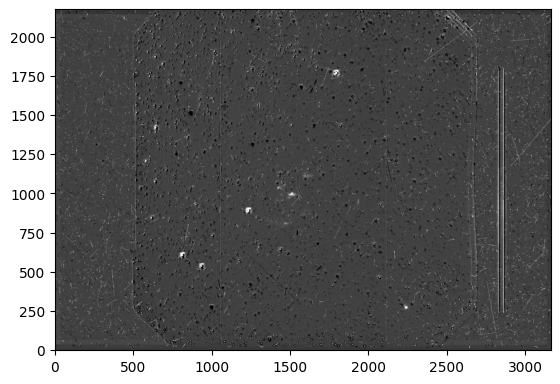

In [26]:
subtracted = oiii_data - oiiic_convolved * 0.42

plt.imshow(subtracted, cmap='gray', origin='lower', vmin=np.percentile(subtracted,1), vmax=np.percentile(subtracted,99.5))
plt.show()

fits.writeto("test_sub4.fits", subtracted, overwrite=True)

In [27]:
# oiii_data = np.asarray(fits.open("images/normalized_OIII.fits")[0].data, dtype=np.float32)
# oiiic_data = np.asarray(fits.open("images/aligned_normalized_OIIIC.fits")[0].data, dtype=np.float32)

# subtracted = oiii_data - oiiic_data * 0.4
# plt.imshow(subtracted, cmap='gray', origin='lower', vmin=np.percentile(subtracted,1), vmax=np.percentile(subtracted,99.5))
# plt.show()

# fits.writeto("test_sub7.fits", subtracted, overwrite=True)

# print("Syb image stats")
# print("Min:", np.min(subtracted))
# print("Max:", np.max(subtracted))
# print("Mean:", np.mean(subtracted))
# print("Stdev:", np.std(subtracted))

In [28]:
# test alignment again

# align images again
import astroalign as aa
import numpy as np

oiiic_hdul = fits.open("images/SNR_OIIIC.fits")
oiiic_header = oiiic_hdul[0].header

source = np.asarray(oiiic_convolved, dtype=np.float32)
target = np.asarray(oiii_data, dtype=np.float32)
convolved_aligned, footprint = aa.register(source, target)
fits.writeto("convolved_aligned.fits", convolved_aligned, header=oiiic_header, overwrite=True)

<frozen importlib._bootstrap>:241: FutureWarning: 
The `sep-pjw` package has reverted to the original `sep` package name. Bug
fixes and additional enhancements will not be released for `sep-pjw`, and
users of this package should update their dependencies to `sep>=1.4.0`.



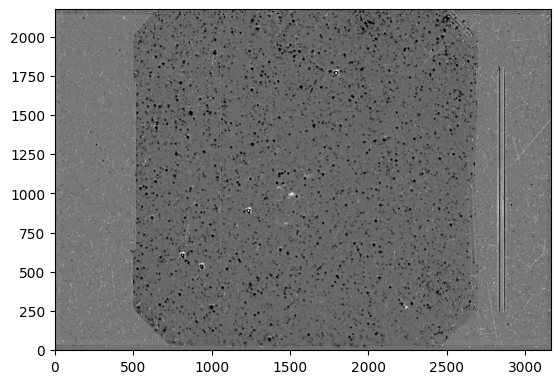

In [29]:
subtracted = oiii_data - convolved_aligned * 0.5

plt.imshow(subtracted, cmap='gray', origin='lower', vmin=np.percentile(subtracted,1), vmax=np.percentile(subtracted,99.5))
plt.show()

fits.writeto("images/csi.fits", subtracted, overwrite=True)

In [30]:
mean, median, std = sigma_clipped_stats(subtracted)
print(np.array((mean, median, std)))

[-0.00259404 -0.00307994  0.0050789 ]


In [31]:
### minimize background with least positive value

best_scale = 1
best_median = 1

for step in range(400, 500):
    
    scale = step/1000
    
    subtracted = oiii_data - convolved_aligned * scale
    mean, median, std = sigma_clipped_stats(subtracted)
    
    print("current scale: ", scale)
    print("current median: ", median)

    if median > 0 and min(median, best_median):
        best_scale = scale
        best_median = median
    

print("best median: ", best_median)
print("best scale: ", best_scale)

current scale:  0.4
current median:  0.0041133985
current scale:  0.401
current median:  0.0040254053
current scale:  0.402
current median:  0.0039388537
current scale:  0.403
current median:  0.0038545094
current scale:  0.404
current median:  0.0037734807
current scale:  0.405
current median:  0.003697291
current scale:  0.406
current median:  0.0036282942
current scale:  0.407
current median:  0.0035662092
current scale:  0.408
current median:  0.003510811
current scale:  0.409
current median:  0.0034610026
current scale:  0.41
current median:  0.0034158786
current scale:  0.411
current median:  0.0033744953
current scale:  0.412
current median:  0.003335963
current scale:  0.413
current median:  0.0032996966
current scale:  0.414
current median:  0.003265102
current scale:  0.415
current median:  0.0032314942
current scale:  0.416
current median:  0.0031990078
current scale:  0.417
current median:  0.003166536
current scale:  0.418
current median:  0.0031345948
current scale:  0.41

KeyboardInterrupt: 